# Edge colouring of complete tripartite graphs with z3

In [1]:
import time
import pygraphviz as pgv
from z3 import *

## 1. Build a complete tripartite graph K(l, m, n)

`create_graph` returns the edge list; `build_graph` wraps it in a pygraphviz `AGraph`.

In [2]:
def create_graph(l, m, n):
    """Edges of the complete tripartite graph K(l, m, n)."""
    edges = []
    for i in range(0, l):
        for j in range(l, l + m):
            edges.append((i, j))
    for i in range(0, l):
        for k in range(l + m, l + m + n):
            edges.append((i, k))
    for j in range(l, l + m):
        for k in range(l + m, l + m + n):
            edges.append((j, k))
    return edges


In [3]:
def build_graph(l, m, n):
    """Build the AGraph for K(l, m, n). Returns (graph, name, layout)."""
    G = pgv.AGraph()
    G.node_attr['style'] = 'filled'
    G.edge_attr['dir'] = 'none'

    edges = create_graph(l, m, n)
    for i in range(l + m + n):
        G.add_node(i)
    for src, dst in edges:
        G.add_edge(src, dst)

    return (G, 'k_%d_%d_%d' % (l, m, n), 'circo')

## 2. Edge helpers

Edges are represented as `"a b"` strings. `all_edges` lists them; `node_nbs` returns every edge that shares an endpoint with the given edge (i.e. its neighbours in the line graph).

In [4]:
def all_edges(graph):
    """All edges of `graph` as 'a b' strings."""
    # OPTIMISATION (point 3): call graph.edges() ONCE instead of graph.edges()[i]
    # inside the loop. The old version rebuilt the whole edge list every
    # iteration -> O(E^2); this is O(E).
    return [u + ' ' + v for u, v in graph.edges()]

#all_edges(graph)

In [5]:
def node_nbs(graph, edge):
    """Edges adjacent to `edge` (sharing either endpoint)."""
    # OPTIMISATION (point 4): split the edge string ONCE and reuse the tokens,
    # instead of calling edge.split(' ') three separate times.
    a, b = edge.split(' ')
    rev = b + ' ' + a                                     # true reverse edge (token swap)
    neighbor_edges = []
    for node in (a, b):
        for nb in graph.neighbors(node):
            nb_edge = node + ' ' + nb
            if nb_edge != edge and nb_edge != rev:
                neighbor_edges.append(nb_edge)
    return neighbor_edges

## 3. Interval edge colouring with z3

A **correct interval colouring** must satisfy two conditions at every vertex:
1. the edges meeting there all get **different** colours
2. those colours form a **consecutive run** with no gaps (e.g. 2,3,4,5), i.e. `max - min == degree - 1`

This is *interval edge colouring*. Δ (max degree) is the lower bound,the search goes from Δ upward and may report that none exists.

In [6]:
def interval_coloring(graph, max_colors=None):
    """Interval edge colouring with z3.

    (1) incident edges are all different
    (2) their colours are CONSECUTIVE (max - min == degree - 1).
    Searches k = Delta, Delta+1, ... up to max_colors (default 2*Delta).

    Returns a result dict:
      {'solution': {edge:colour} or None, 'colorable': bool,
       'colours': k or None, 'colours_tested': int,
       'delta': int, 'max_colors': int}
    """
    edges = all_edges(graph)
    idx = {e: i for i, e in enumerate(edges)}
    xs = [Int('e%d' % i) for i in range(len(edges))]

    inc = {}
    for i, e in enumerate(edges):
        u, v = e.split(' ')
        inc.setdefault(u, []).append(i)
        inc.setdefault(v, []).append(i)

    delta = max(len(es) for es in inc.values())
    if max_colors is None:
        max_colors = 2 * delta

    # OPTIMISATION (point 1): build the solver ONCE and solve incrementally.
    # The k-independent constraints are added a single time; only the upper
    # bound x <= k-1 changes per k -> push()/pop().
    #
    # OPTIMISATION (point 2): encode "consecutive colours" with a per-vertex
    # window-start variable `lo` plus linear bounds  lo <= x <= lo + degree - 1,
    # instead of the nested-If  zmax(vs) - zmin(vs) == degree - 1.
    # Combined with Distinct this accepts EXACTLY the same colourings (a window
    # of width d that must hold d distinct values contains precisely those d
    # consecutive values), but uses plain arithmetic instead of branching
    # If-terms -> much faster for z3.  Distinct is what makes the trick sound;
    
    s = Solver()
    for x in xs:
        s.add(x >= 0)
    for v, es in inc.items():
        vs = [xs[i] for i in es]
        s.add(Distinct(vs))                                 # condition 1
        if len(vs) > 1:
            lo = Int('lo_%s' % v)                           # window start for vertex v
            for x in vs:
                s.add(x >= lo, x <= lo + len(vs) - 1)       # condition 2 (consecutive)

    tested = 0
    for k in range(delta, max_colors + 1):
        tested += 1
        s.push()
        for x in xs:
            s.add(x <= k - 1)
        if s.check() == sat:
            print('OK, interval colouring found with %d colours' % k)
            m = s.model()
            sol = {e: m[xs[idx[e]]].as_long() for e in edges}
            return {'solution': sol, 'colorable': True, 'colours': k,
                    'colours_tested': tested, 'delta': delta, 'max_colors': max_colors}
        s.pop()

    print('No interval colouring found with up to %d colours' % max_colors)
    return {'solution': None, 'colorable': False, 'colours': None,
            'colours_tested': tested, 'delta': delta, 'max_colors': max_colors}

## 3b. Solution → matrix

`color_matrix` turns an edge-colour solution into a matrix, `*` marks cells with no edge, including the diagonal. `format_matrix` renders it as aligned text for saving/printing.

In [7]:
def color_matrix(graph, solution):
    """edge-colour matrix; '*' where there is no edge."""
    nodes = sorted(graph.nodes(), key=int)
    idx = {node: i for i, node in enumerate(nodes)}
    M = [['*'] * len(nodes) for _ in nodes]
    for e_str, color in solution.items():
        u, v = e_str.split(' ')
        M[idx[u]][idx[v]] = str(color)
        M[idx[v]][idx[u]] = str(color)
    return nodes, M


def format_matrix(nodes, M):
    """Render the matrix as aligned text with node labels on row/col."""
    w = max([len(x) for row in M for x in row] + [len(x) for x in nodes]) + 1
    lines = [' ' * w + ''.join(x.rjust(w) for x in nodes)]
    for label, row in zip(nodes, M):
        lines.append(label.rjust(w) + ''.join(x.rjust(w) for x in row))
    return '\n'.join(lines)


def format_kmn(name, solution):
    """
    Rows = part A (size l) then part B (size m); columns = part A (size l)
    then part C (size n). '*' marks no-edge cells (the A x A block).
    """
    l, m, n = (int(t) for t in name.split('_')[1:])
    row_nodes = [str(v) for v in range(l + m)]                              # A, then B
    col_nodes = [str(v) for v in list(range(l)) + list(range(l + m, l + m + n))]  # A, then C

    def cell(u, v):
        c = solution.get(u + ' ' + v)
        if c is None:
            c = solution.get(v + ' ' + u)
        return '*' if c is None else str(c)

    grid = [[cell(r, c) for c in col_nodes] for r in row_nodes]
    w = max(len(x) for row in grid for x in row)
    rows_txt = [' ' + ' | '.join(x.rjust(w) for x in row) + ' |' for row in grid]
    width = max(len(r) for r in rows_txt)
    rule = ' ' + '-' * (width - 1)

    lines = [('K ' + ' '.join(str(s) for s in (l, m, n))).center(width), '']
    for r in rows_txt:
        lines.append(r)
        lines.append(rule)
    return '\n'.join(lines)


def render_matrix(name, graph, solution):
    parts = name.split('_')
    if parts[0] == 'k' and len(parts) == 4 and all(p.isdigit() for p in parts[1:]):
        return format_kmn(name, solution)
    nodes, M = color_matrix(graph, solution)
    return format_matrix(nodes, M)


def log_solution(name, graph, res, runtime, path='solutions.txt'):
    """Append a summary of one run to the combined solutions file: runtime,
    how many colour-counts were tested, whether the graph was colourable, and
    (if so) the solution matrix appends.
    Entries accumulate across runs."""
    
    lo = res['delta']
    hi = lo + res['colours_tested'] - 1
    lines = ['=== %s ===' % name,
             'colourable     : %s' % ('yes' if res['colorable'] else 'no'),
             'colours tested : %d  (k = %d .. %d)' % (res['colours_tested'], lo, hi),
             'runtime        : %.3f s' % runtime]
    if res['colorable']:
        lines.append('colours used   : %d' % res['colours'])
        lines.append('solution matrix:')
        lines.append(render_matrix(name, graph, res['solution']))
    lines.append('')
    with open(path, 'a') as f:
        f.write('\n'.join(lines) + '\n')
    print('Appended result for %s to %s' % (name, path))

In [20]:
l,m,n = 1,1,2

## 4. Run

Build K(l, m, n) and colour its edges.

In [21]:
x, name, layout = build_graph(l, m, n)
print('Graph %r: %d nodes, %d edges' % (name, x.number_of_nodes(), x.number_of_edges()))

t1 = time.time()
res = interval_coloring(x)
t2 = time.time()
runtime = t2 - t1

if not res['colorable']:
    print('This graph has no interval colouring in the searched range.')
else:
    print('solution (in %.3fs):' % runtime)
    print(res['solution'])
    print()
    print('Minimum colours for an interval colouring: %d' % res['colours'])
    print('  (max degree Delta = %d is a hard lower bound)' % res['delta'])
    print('Colour counts tested: %d (searched upward from Delta)' % res['colours_tested'])

# save this run to the combined solutions file
log_solution(name, x, res, runtime)

Graph 'k_1_1_2': 4 nodes, 5 edges
OK, interval colouring found with 3 colours
solution (in 0.012s):
{'0 1': 2, '0 2': 0, '0 3': 1, '1 2': 1, '1 3': 0}

Minimum colours for an interval colouring: 3
  (max degree Delta = 3 is a hard lower bound)
Colour counts tested: 1 (searched upward from Delta)
Appended result for k_1_1_2 to solutions.txt


## 4b. Per-k solver effort (visualizing the search)

The loop in section 3 tries `k = Delta, Delta+1, ...` until z3 reports `sat` (or gives up at
`max_colors`). Z3 doesn't expose a step-by-step trace of its internal decisions, but after every
`check()` call it reports aggregate effort via `Solver.statistics()` -- how many decisions,
conflicts, propagations and restarts that call took.

`interval_coloring_instrumented` is a copy of `interval_coloring` that records those numbers,
plus wall-clock time, for every `k` it tries. The chart shows how much work z3 does *proving each
k too small* before it lands on (or fails to find) a working colouring -- most of the effort is
usually spent on the unsat calls, with the final sat call appearing all at once rather than
building up gradually.

In [18]:
def interval_coloring_instrumented(graph, max_colors=None):
    """Same search as interval_coloring, but records per-k solver effort.

    Returns (res, stats):
      res   -- identical in shape to interval_coloring's return value
      stats -- one dict per k tried: {'k', 'sat', 'time',
               'decisions', 'conflicts', 'propagations', 'restarts'}
    """
    edges = all_edges(graph)
    idx = {e: i for i, e in enumerate(edges)}
    xs = [Int('e%d' % i) for i in range(len(edges))]

    inc = {}
    for i, e in enumerate(edges):
        u, v = e.split(' ')
        inc.setdefault(u, []).append(i)
        inc.setdefault(v, []).append(i)

    delta = max(len(es) for es in inc.values())
    if max_colors is None:
        max_colors = 2 * delta

    s = Solver()
    for x in xs:
        s.add(x >= 0)
    for v, es in inc.items():
        vs = [xs[i] for i in es]
        s.add(Distinct(vs))
        if len(vs) > 1:
            lo = Int('lo_%s' % v)
            for x in vs:
                s.add(x >= lo, x <= lo + len(vs) - 1)

    stats = []
    res = None
    for k in range(delta, max_colors + 1):
        s.push()
        for x in xs:
            s.add(x <= k - 1)
        t0 = time.time()
        outcome = s.check()
        elapsed = time.time() - t0
        st = s.statistics()
        
        d = {key: st.get_key_value(key) for key in st.keys()}
        stats.append({
            'k': k, 'sat': outcome == sat, 'time': elapsed,
            'decisions': d.get('decisions', 0),
            'conflicts': d.get('conflicts', 0),
            'propagations': d.get('propagations', 0),
            'restarts': d.get('restarts', 0),
        })
        if outcome == sat:
            m = s.model()
            sol = {e: m[xs[idx[e]]].as_long() for e in edges}
            res = {'solution': sol, 'colorable': True, 'colours': k,
                   'colours_tested': len(stats), 'delta': delta, 'max_colors': max_colors}
            s.pop()
            break
        s.pop()
    else:
        res = {'solution': None, 'colorable': False, 'colours': None,
               'colours_tested': len(stats), 'delta': delta, 'max_colors': max_colors}

    return res, stats


k    sat    time(s)  decisions  conflicts  propagations  restarts 
7    True   0.0205   289        128        910           1        


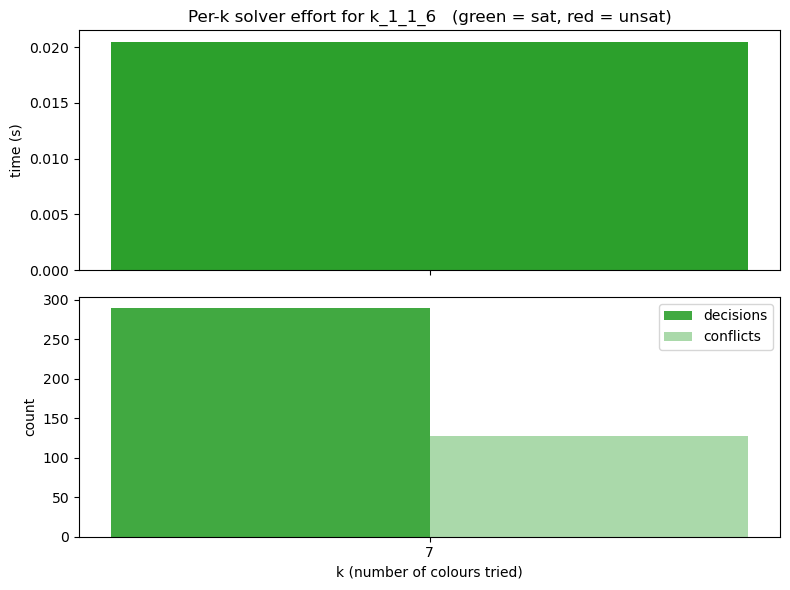

In [19]:
import matplotlib.pyplot as plt

res_i, stats = interval_coloring_instrumented(x)

hdr = '%-4s %-6s %-8s %-10s %-10s %-13s %-9s'
row = '%-4d %-6s %-8.4f %-10d %-10d %-13d %-9d'
print(hdr % ('k', 'sat', 'time(s)', 'decisions', 'conflicts', 'propagations', 'restarts'))
for d in stats:
    print(row % (d['k'], d['sat'], d['time'], d['decisions'], d['conflicts'], d['propagations'], d['restarts']))

ks = [d['k'] for d in stats]
times = [d['time'] for d in stats]
decisions = [d['decisions'] for d in stats]
conflicts = [d['conflicts'] for d in stats]
bar_colors = ['#2ca02c' if d['sat'] else '#d62728' for d in stats]   # green = sat, red = unsat

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].bar(ks, times, color=bar_colors)
axes[0].set_ylabel('time (s)')
axes[0].set_title('Per-k solver effort for %s   (green = sat, red = unsat)' % name)

width = 0.4
axes[1].bar([k - width / 2 for k in ks], decisions, width=width, color=bar_colors, alpha=0.9, label='decisions')
axes[1].bar([k + width / 2 for k in ks], conflicts, width=width, color=bar_colors, alpha=0.4, label='conflicts')
# spans several orders of magnitude on larger graphs -> try axes[1].set_yscale('log') then
axes[1].set_ylabel('count')
axes[1].set_xlabel('k (number of colours tried)')
axes[1].set_xticks(ks)
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Draw the coloured graph

Draws the graph with each part on its own row (same colour per row) and edges coloured + labelled with their colour number. Change `part_fill` for the node/row colours and `edge_palette` for the edge colours.

In [ ]:
# Draw the coloured graph: nodes coloured by part (same row = same colour).
# Layout rules:
#   * every part sits on its own horizontal line,
#   * the part with the FEWEST nodes is pinned to the TOP (2 nodes on top),
#   * the part with the MOST nodes is pinned to the BOTTOM,
#   * generous spacing + spline routing so nodes never overlap and edges
#     curve AROUND nodes instead of crossing over them,
#   * edges coloured and labelled with their colour number.
if not res['colorable']:
    print('No colouring to draw for %s.' % name)
else:
    sol = res['solution']
    sizes = [int(t) for t in name.split('_')[1:]]      # 'k_2_3_4' -> [2, 3, 4]

    # >>> CHANGE NODE COLOURS HERE (one per row/part) <<<
    part_fill = ['lightsalmon', 'lightblue', 'lightgreen', 'khaki', 'plum']
    # >>> CHANGE EDGE COLOURS HERE (indexed by each edge's colour number) <<<
    edge_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown',
                    'cyan', 'magenta', 'darkgreen', 'gray', 'gold', 'navy']

    # node index range for each ORIGINAL part: part p owns nodes [start, start+size)
    starts, node = [], 0
    for size in sizes:
        starts.append(node)
        node += size
    part_nodes_by_part = [[str(starts[p] + i) for i in range(sizes[p])]
                          for p in range(len(sizes))]

    # vertical order of the rows: smallest part on TOP, largest part on BOTTOM
    row_order = sorted(range(len(sizes)), key=lambda p: sizes[p])
    n_rows = len(row_order)

    # spacing so nodes never overlap and edges have room to route AROUND nodes
    x.graph_attr['nodesep'] = '0.6'    # horizontal gap between nodes in a row
    x.graph_attr['ranksep'] = '1.2'    # vertical gap between rows (room for splines)
    x.graph_attr['splines'] = 'true'   # draw edges as curves that avoid nodes

    for row_pos, p in enumerate(row_order):
        part_nodes = part_nodes_by_part[p]
        for nd in part_nodes:
            n = x.get_node(nd)
            n.attr['style'] = 'filled'
            n.attr['fillcolor'] = part_fill[p % len(part_fill)]
        # top row -> rank 'min', bottom row -> rank 'max', middle rows -> 'same'
        rank = 'min' if row_pos == 0 else ('max' if row_pos == n_rows - 1 else 'same')
        sub = x.add_subgraph(part_nodes, name='row_%d' % row_pos, rank=rank)
        # invisible chain keeps the row in increasing left-to-right order
        for a, b in zip(part_nodes, part_nodes[1:]):
            sub.add_edge(a, b, style='invis')

    # colour AND number each edge
    for e_str, color in sol.items():
        u, v = e_str.split(' ')
        e = x.get_edge(u, v)
        c = edge_palette[color % len(edge_palette)]
        e.attr['color'] = c
        e.attr['fontcolor'] = c
        e.attr['label'] = str(color)

    from IPython.display import Image, display
    # prog='dot' forces the layered engine that stacks the rows.
    # (pygraphviz's draw() defaults to neato, which would scramble the rows.)
    display(Image(x.draw(prog='dot', format='png')))   # show inline (NOT saved to disk)


Save to HTML

In [ ]:
import base64

png_bytes = x.draw(prog='dot', format='png')
out_path  = 'solutions.html'

html = ['<section style="font-family:monospace;text-align:center;'
        'max-width:800px;margin:24px auto;'
        'border-bottom:1px solid #ccc;padding-bottom:16px">']
html.append('<h2>%s</h2>' % name)

# each field on its own line
html.append('<div>colourable: <b>%s</b></div>' % ('yes' if res['colorable'] else 'no'))
if res['colorable']:
    html.append('<div>colours used: <b>%d</b></div>' % res['colours'])
    html.append('<div>runtime: %.3f s</div>' % runtime)
    # solution matrix
    html.append('<pre style="background:#f6f6f6;padding:8px;'
                'display:inline-block;text-align:left">%s</pre>'
                % render_matrix(name, x, res['solution']))
    # image
    b64 = base64.b64encode(png_bytes).decode('ascii')
    html.append('<div><img src="data:image/png;base64,%s" '
                'style="max-width:640px;border:1px solid #ddd"></div>' % b64)
html.append('</section>')

with open(out_path, 'a') as f:
    f.write('\n'.join(html) + '\n')
print('saved image + matrix ->', out_path)

## 6. Verify the re-encoding

Two independent checks that point 2 preserves behaviour:

* **Check 1 - matches the original encoding.** `interval_coloring_ref` re-implements
  the ORIGINAL nested-If encoding (`zmax - zmin == degree - 1`). For every test
  graph the re-encoded solver must report the same `colorable` and the same
  minimum number of colours `k`.
* **Check 2 - independent validity.** `verify_interval` checks the RETURNED
  colouring directly in plain Python (no z3): at every vertex the colours are
  all different and form a consecutive run with no gaps.

In [ ]:
# from collections import defaultdict


# def verify_interval(solution):
#     """Plain-Python validity check of an interval edge colouring:
#     at every vertex the colours are all different AND consecutive (no gaps)."""
#     at = defaultdict(list)
#     for e_str, c in solution.items():
#         u, v = e_str.split(' ')
#         at[u].append(c)
#         at[v].append(c)
#     for v, cols in at.items():
#         assert len(cols) == len(set(cols)), 'vertex %s: colours repeat' % v      # rule 1
#         assert max(cols) - min(cols) == len(cols) - 1, 'vertex %s: gap' % v      # rule 2
#     return True


# def interval_coloring_ref(graph, max_colors=None):
#     """Reference solver using the ORIGINAL nested-If encoding
#     (zmax - zmin == degree - 1). Used ONLY to cross-check the minimum k."""
#     edges = all_edges(graph)
#     xs = [Int('e%d' % i) for i in range(len(edges))]
#     inc = {}
#     for i, e in enumerate(edges):
#         u, v = e.split(' ')
#         inc.setdefault(u, []).append(i)
#         inc.setdefault(v, []).append(i)
#     delta = max(len(es) for es in inc.values())
#     if max_colors is None:
#         max_colors = 2 * delta

#     def zmax(lst):
#         m = lst[0]
#         for e in lst[1:]:
#             m = If(e > m, e, m)
#         return m

#     def zmin(lst):
#         m = lst[0]
#         for e in lst[1:]:
#             m = If(e < m, e, m)
#         return m

#     for k in range(delta, max_colors + 1):
#         s = Solver()
#         for x in xs:
#             s.add(x >= 0, x <= k - 1)
#         for v, es in inc.items():
#             vs = [xs[i] for i in es]
#             s.add(Distinct(vs))
#             if len(vs) > 1:
#                 s.add(zmax(vs) - zmin(vs) == len(vs) - 1)
#         if s.check() == sat:
#             return {'colorable': True, 'colours': k}
#     return {'colorable': False, 'colours': None}


# # Small, fast, tractable graphs. NOTE: larger complete tripartite graphs
# # such as (2,3,4) or (3,3,3) are SLOW for BOTH encodings (the upward search
# # hits hard UNSAT proofs), so they are left out of this quick self-check.
# cases = [(2, 1, 4), (2, 2, 4), (1, 2, 3), (2, 2, 2)]
# hdr = '%-9s %-10s %-8s %-6s %-7s %-7s'
# print(hdr % ('graph', 'colorable', 'colours', 'delta', 'valid?', '==ref?'))
# for (l, m, n) in cases:
#     G, nm, _ = build_graph(l, m, n)
#     r = interval_coloring(G)               # re-encoded (points 1 + 2)
#     ref = interval_coloring_ref(G)         # original encoding
#     valid = verify_interval(r['solution']) if r['colorable'] else None
#     same = (r['colorable'] == ref['colorable']) and (r['colours'] == ref['colours'])
#     print(hdr % (nm, r['colorable'], r['colours'], r['delta'], valid, same))
#     assert same, 'MISMATCH vs reference on %s' % nm

# print('\nCheck 1 (matches original encoding) and Check 2 (independent validity) both PASS.')

## 7. Benchmark: re-encoding (points 1+2) vs the original encoding

Head-to-head wall-clock comparison on the SAME graphs and the SAME search range:

* **`ref(orig)`** = `bench_ref` - the ORIGINAL nested-If encoding
  (`zmax - zmin == degree - 1`), a fresh solver rebuilt per `k`. This is the
  baseline (what `updated_version.ipynb` does).
* **`new(1+2)`** = `bench_new` - the re-encoded (`lo`-window) + incremental
  (one solver, push/pop) solver. Same constraints, different encoding.

`speedup = ref_s / new_s` (>1 means the re-encoding is faster). A `per-check`
z3 timeout bounds hard instances: a cell reported as `timeout@k` means that
`k`'s satisfiability check hit the time limit, so its row is a lower bound only
- trust the speedup on rows where BOTH sides completed (no `timeout`).

In [ ]:
# import time

# PER_CHECK_MS = 8000   # z3 timeout per satisfiability check (bounds hard instances)


# def bench_new(graph, per_check_ms):
#     """Re-encoded (lo-window) + incremental solver. Returns (label, seconds)."""
#     edges = all_edges(graph)
#     xs = [Int('e%d' % i) for i in range(len(edges))]
#     inc = {}
#     for i, e in enumerate(edges):
#         u, v = e.split(' ')
#         inc.setdefault(u, []).append(i)
#         inc.setdefault(v, []).append(i)
#     delta = max(len(es) for es in inc.values())
#     max_colors = 2 * delta
#     s = Solver()
#     s.set('timeout', per_check_ms)
#     for x in xs:
#         s.add(x >= 0)
#     for v, es in inc.items():
#         vs = [xs[i] for i in es]
#         s.add(Distinct(vs))
#         if len(vs) > 1:
#             lo = Int('lo_%s' % v)
#             for x in vs:
#                 s.add(x >= lo, x <= lo + len(vs) - 1)
#     t0 = time.time()
#     for k in range(delta, max_colors + 1):
#         s.push()
#         for x in xs:
#             s.add(x <= k - 1)
#         r = s.check()
#         if r == sat:
#             return (k, time.time() - t0)
#         if r == unknown:
#             return ('timeout@%d' % k, time.time() - t0)
#         s.pop()
#     return ('no', time.time() - t0)


# def bench_ref(graph, per_check_ms):
#     """Original nested-If encoding, solver rebuilt per k. Returns (label, seconds)."""
#     edges = all_edges(graph)
#     xs = [Int('e%d' % i) for i in range(len(edges))]
#     inc = {}
#     for i, e in enumerate(edges):
#         u, v = e.split(' ')
#         inc.setdefault(u, []).append(i)
#         inc.setdefault(v, []).append(i)
#     delta = max(len(es) for es in inc.values())
#     max_colors = 2 * delta

#     def zmax(lst):
#         m = lst[0]
#         for e in lst[1:]:
#             m = If(e > m, e, m)
#         return m

#     def zmin(lst):
#         m = lst[0]
#         for e in lst[1:]:
#             m = If(e < m, e, m)
#         return m

#     t0 = time.time()
#     for k in range(delta, max_colors + 1):
#         s = Solver()
#         s.set('timeout', per_check_ms)
#         for x in xs:
#             s.add(x >= 0, x <= k - 1)
#         for v, es in inc.items():
#             vs = [xs[i] for i in es]
#             s.add(Distinct(vs))
#             if len(vs) > 1:
#                 s.add(zmax(vs) - zmin(vs) == len(vs) - 1)
#         r = s.check()
#         if r == sat:
#             return (k, time.time() - t0)
#         if r == unknown:
#             return ('timeout@%d' % k, time.time() - t0)
#     return ('no', time.time() - t0)


# bench_cases = [(2, 1, 4), (2, 2, 4), (1, 2, 3), (2, 2, 2), (2, 3, 4), (3, 3, 3)]
# hdr = '%-9s %-6s %-11s %-9s %-11s %-9s %-8s'
# print(hdr % ('graph', 'edges', 'new(1+2)', 'new_s', 'ref(orig)', 'ref_s', 'speedup'))
# for (l, m, n) in bench_cases:
#     G, nm, _ = build_graph(l, m, n)
#     E = G.number_of_edges()
#     nk, ns = bench_new(G, PER_CHECK_MS)
#     rk, rs = bench_ref(G, PER_CHECK_MS)
#     both_done = ('timeout' not in str(nk)) and ('timeout' not in str(rk))
#     sp = ('%.2fx' % (rs / ns)) if (both_done and ns > 0) else '(bounded)'
#     print(hdr % (nm, E, nk, '%.3f' % ns, rk, '%.3f' % rs, sp))